---
tags: [tutorial]
---

# パラメータ付き量子カーネル

チュートリアル01では、固定数の量子ビットを持つ量子カーネルを構築しました。Qamomileでは量子ビット数やレイヤー数といった回路の構造を決めるような値をシンボリックなパラメータとして扱うことができます。例えば、`n`量子ビットを用意して、各量子ビットにHゲートを作用させるというような量子カーネルを書いたり、`p`回分、特定のゲート列を掛けるといった量子カーネルを書くことができます。このような回路構造そのものを定めるパラメータと、引数として与える回転ゲートの角度パラメータ（例えば、変分パラメータ）はQamomileにおいて固定する必要があるタイミングが異なります。端的に言えば、回路構造を定めるパラメータはトランスパイル時に、回転角度のようなパラメータは実行時（ランタイム）に固定する必要があります。

この章では以下を学びます：

- 量子カーネル入力における`UInt`と`Float`の役割
- パラメータ化された回路のための`qubit_array()`と`qmc.range()`
- **バインド/スイープパターン**：一度トランスパイルし、複数回実行する

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

## `UInt`と`Float`の役割

量子カーネルのパラメータは典型的には大きく2種類に分かれます：

| 型 | 典型的な役割 |
|------|-------------|
| `qmc.UInt` | 回路構造（量子ビット数、ループ回数） |
| `qmc.Float` | ゲートパラメータ（回転角度、重み） |

`qubit_array`のサイズや`qmc.range`の回数を制御する`UInt`はトランスパイル先の量子SDKが固定の回路構造を必要とするため、トランスパイル時にバインドする**必要があります**。一方`Float`はスイープ可能なパラメータとして残せます。

典型的なパターンは、構造をトランスパイル時に固定し、ゲートパラメータを実行時にスイープすることです。

In [2]:
import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## `qubit_array`と`qmc.range`

量子ビット数がパラメータ`n`に依存する場合、`qubit_array(n)`を使用します。配列をループするには、Python組み込みの`range()`ではなく`qmc.range(n)`を使用します。`qmc.range`はPythonの`range()`と同様に`start`、`stop`、`step`引数を取ります。例えば、すべての偶数番目の量子ビットにゲートを適用したい場合は、`for i in qmc.range(0, n, 2): ...`と書くことができます。

> **なぜPythonの`range()`ではダメなのか？**：トレース時に`n`はシンボルであり、Pythonの整数ではありません。Pythonの`range()`はシンボルに対して反復できないため、代わりに`qmc.range()`を使います。`qmc.range()`はIR内に**ループノード**を生成し、`n`が具体的な値にバインドされた時点でトランスパイラが展開します。

In [3]:
@qmc.qkernel
def rotation_layer(n: qmc.UInt, theta: qmc.Float) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
        q[i] = qmc.ry(q[i], theta)

    return qmc.measure(q)

`draw()`はパラメータを具体的な値にバインドするキーワード引数を受け取ります。ここでは`n=4`で回路を4量子ビットに固定し、`theta=0.3`でプレースホルダーの角度を指定しています。

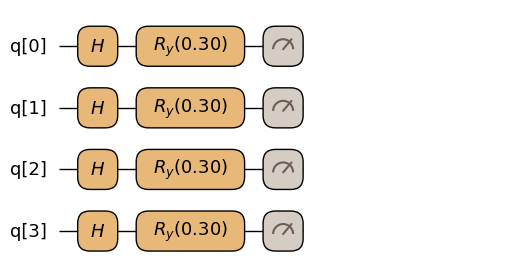

In [4]:
rotation_layer.draw(n=4, theta=0.3, fold_loops=False)

## インデックスベースの更新

パターン`q[i] = qmc.h(q[i])`に注意してください。Qamomileにおいて量子ハンドルはアフィン型であるため、アクセスされた量子ビットは消費され、更新されたハンドルを同じ場所に格納する必要があります。

**アンチパターン：配列を直接イテレートする。**`for qi in q:`のように量子ビット配列を直接イテレートする書き方はQamomileがアフィン型を担保できないため、意図的にエラーを出すようにしています。

In [5]:
try:

    @qmc.qkernel
    def bad_iteration(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
        q = qmc.qubit_array(n, name="q")
        for qi in q:  # 直接イテレーション — ダメ！
            qi = qmc.h(qi)
        return q

    bad_iteration.draw(n=4)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")

Error type: SyntaxError
Error message: Direct iteration over sequences is not supported in @qkernel functions.
Line 4: 'for qi in q:'

Direct iteration cannot modify elements in-place, leading to silent bugs.
Use explicit index-based iteration instead:

  # Incorrect (current code):
  for qi in q:
      qi = qmc.operation(qi)

  # Correct:
  n = q.shape[0]
  for i in qmc.range(n):
      q[i] = qmc.operation(q[i])



常にインデックスベースのアクセスを使用してください：`for i in qmc.range(n): q[i] = qmc.h(q[i])`。

## 単一量子ビットゲートを配列にブロードキャストする

同じ単一量子ビットゲートをレジスタ全体の各量子ビットに適用する場合は、インデックスのループを書く代わりに、配列をそのままゲートに渡せます。これは `for i in qmc.range(n): q[i] = qmc.gate(q[i])` と同じ明示ループの記法と等価で、内部的にも同一のIRループに展開されるため、リソース見積もり、トランスパイル、可視化のいずれにおいても挙動は変わりません。回転ゲートの場合は、同一のスカラ角度がすべての量子ビットに適用されます。量子ビットごとに異なる角度を渡す場合は、引き続き明示ループでパラメータベクトルをインデックスする必要があります。

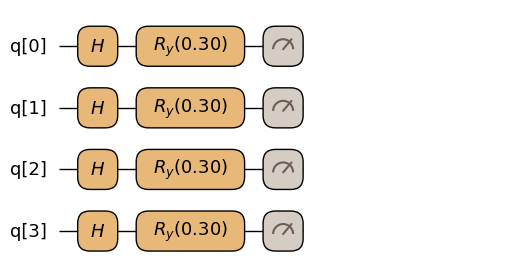

In [6]:
@qmc.qkernel
def rotation_layer_broadcast(n: qmc.UInt, theta: qmc.Float) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q = qmc.h(q)
    q = qmc.ry(q, theta)
    return qmc.measure(q)


rotation_layer_broadcast.draw(n=4, theta=0.3, fold_loops=False)

`rotation_layer`（上）と `rotation_layer_broadcast` は同じ回路を生成します。レジスタ全体に同一のゲートを並べる「層」を書くときはブロードキャスト記法が慣用的な選択です。各量子ビットに異なる角度（例：`Vector[Float]`をインデックスする）を渡したい場合や、レジスタの一部のみを操作する場合は、引き続き明示ループを使ってください。

## バインド/スイープパターン

パラメータ付き量子カーネルの中心となるワークフローパターンです：

1. **一度のみトランスパイル**：構造パラメータ（`n`）をバインド、ゲートパラメータ（`theta`）をスイープ可能なパラメータとして宣言します。
2. **複数回実行**：トランスパイル済みのオブジェクトを異なるランタイムバインディングで再利用します。

これにより、パラメータ値を変えるたびに回路を再トランスパイルする必要がなくなります。

In [7]:
# トランスパイル：n=4を固定し、thetaをスイープ可能なパラメータとして保持
exe = transpiler.transpile(
    rotation_layer,
    bindings={"n": 4},
    parameters=["theta"],
)

# スイープ：同じ実行可能オブジェクトを異なるtheta値で実行
for theta in [0.1, 0.5, 1.0]:
    result = exe.sample(
        transpiler.executor(),
        shots=128,
        bindings={"theta": theta},
    ).result()
    print(f"theta={theta:.1f} -> {result.results}")

theta=0.1 -> [((1, 0, 1, 0), 6), ((0, 1, 1, 0), 6), ((1, 0, 0, 1), 6), ((0, 1, 0, 0), 1), ((1, 1, 1, 1), 7), ((1, 0, 1, 1), 12), ((0, 0, 0, 0), 6), ((0, 0, 1, 0), 9), ((0, 0, 1, 1), 8), ((0, 1, 1, 1), 11), ((0, 0, 0, 1), 7), ((1, 0, 0, 0), 5), ((1, 1, 0, 0), 11), ((1, 1, 1, 0), 11), ((1, 1, 0, 1), 15), ((0, 1, 0, 1), 7)]
theta=0.5 -> [((0, 0, 0, 1), 2), ((1, 0, 0, 1), 4), ((1, 1, 0, 1), 5), ((1, 1, 0, 0), 5), ((1, 0, 0, 0), 2), ((0, 1, 1, 0), 7), ((0, 0, 1, 0), 3), ((0, 0, 1, 1), 6), ((0, 1, 1, 1), 13), ((1, 1, 1, 0), 10), ((1, 0, 1, 1), 16), ((1, 1, 1, 1), 40), ((1, 0, 1, 0), 9), ((0, 1, 0, 1), 6)]
theta=1.0 -> [((0, 1, 1, 0), 1), ((0, 1, 1, 1), 10), ((1, 0, 1, 1), 6), ((1, 1, 0, 1), 2), ((1, 1, 1, 0), 5), ((1, 1, 1, 1), 104)]


トランスパイル済みオブジェクトは3回の実行すべてで再利用されます。変わるのは実行時のバインディング`{"theta": theta}`だけです。

まとめると：

- `bindings={"n": 4}`（トランスパイル時）：回路構造を固定
- `parameters=["theta"]`（トランスパイル時）：`theta`をスイープ可能として宣言
- `bindings={"theta": ...}`（実行時）：具体的な値を指定

## まとめ

- 回路構造（量子ビット数、ループ回数）を制御する`qmc.UInt`は通常トランスパイル時にバインドします。`qmc.Float`（ゲートパラメータ）は実行時スイープの候補です。
- パラメータ化された回路には`qmc.qubit_array(n)`と`qmc.range(n)`を使います。常にインデックスベースの更新`q[i] = qmc.gate(q[i])`を使ってください。
- バインド/スイープパターン — `transpile(bindings=..., parameters=...)` → ループ — で一度だけトランスパイルして複数回実行できます。

**次へ**：[リソース推定](03_resource_estimation.ipynb) — シンボリックなコスト分析、ゲート内訳、スケーリング分析。